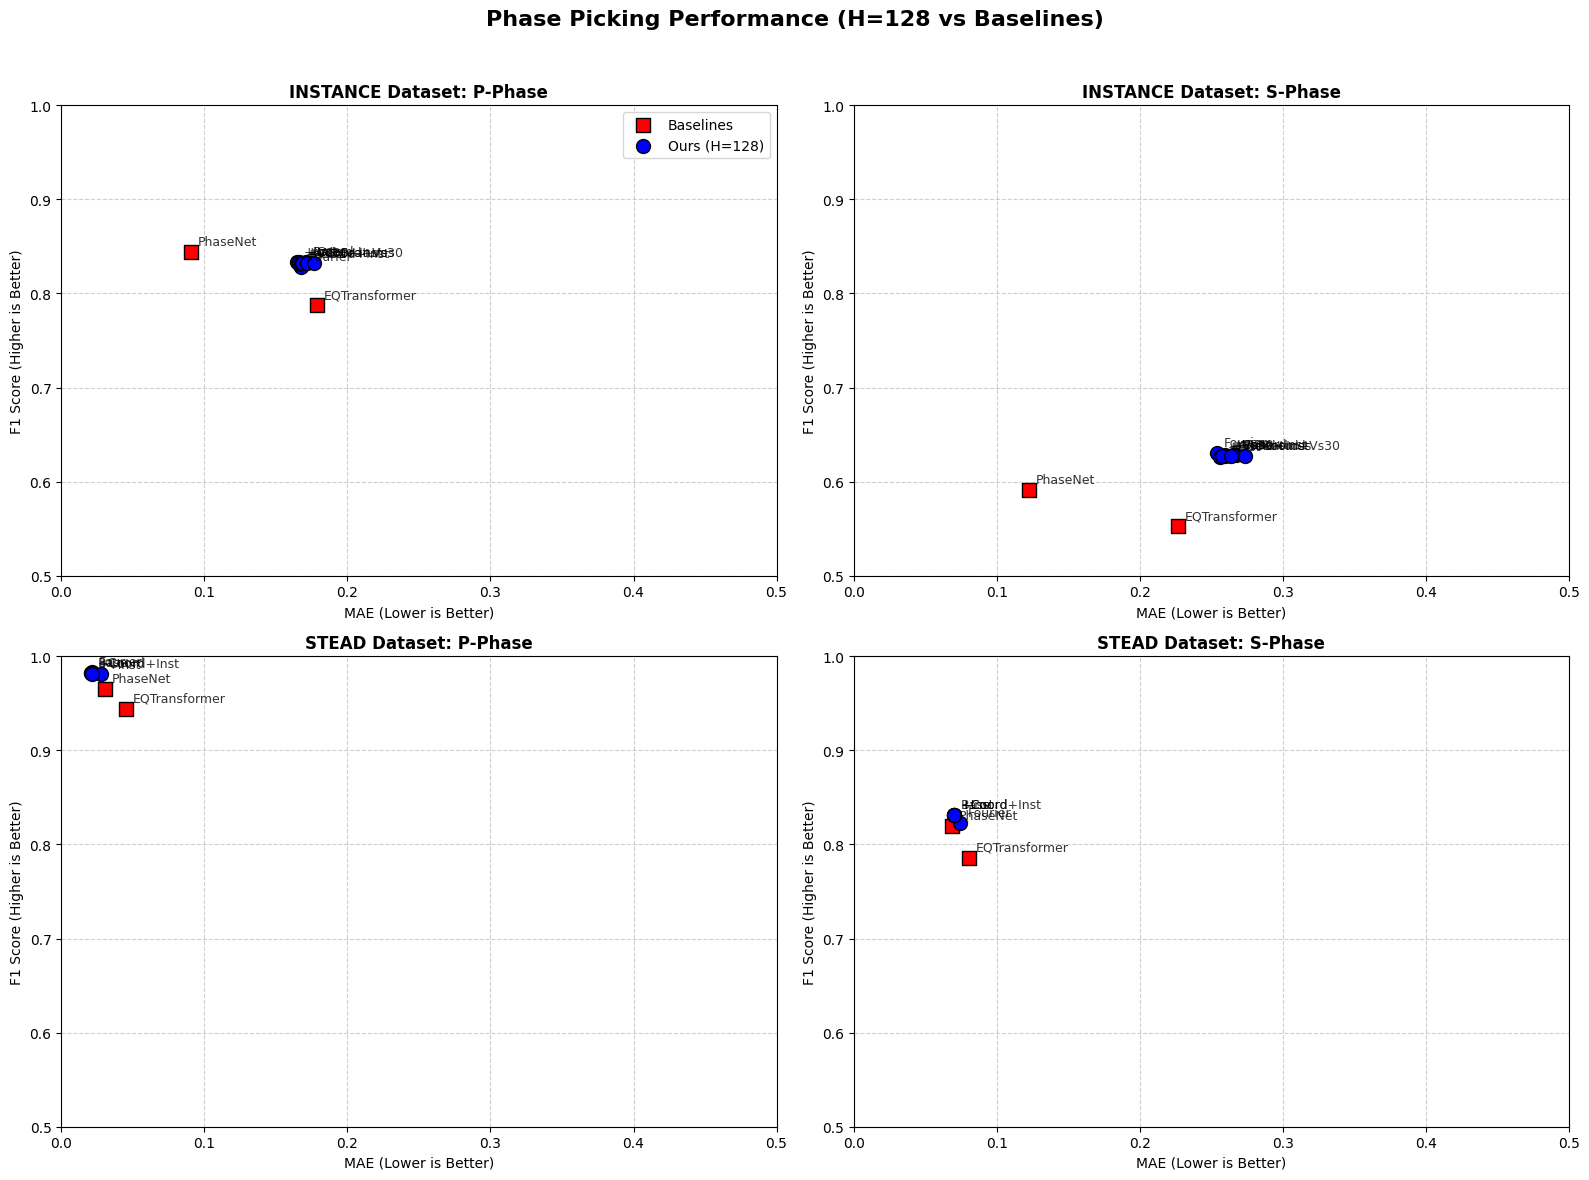

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

data = [
    {'Dataset': 'STEAD', 'Type': 'Baseline', 'Model': 'EQTransformer', 'MAE_P': 0.0454, 'F1_P': 0.9442, 'MAE_S': 0.0806, 'F1_S': 0.7860},
    {'Dataset': 'STEAD', 'Type': 'Baseline', 'Model': 'PhaseNet', 'MAE_P': 0.0307, 'F1_P': 0.9657, 'MAE_S': 0.0688, 'F1_S': 0.8201},
    {'Dataset': 'STEAD', 'Type': 'Ours', 'Model': 'Fourier', 'MAE_P': 0.0213, 'F1_P': 0.9830, 'MAE_S': 0.0746, 'F1_S': 0.8230},
    {'Dataset': 'STEAD', 'Type': 'Ours', 'Model': 'Base', 'MAE_P': 0.0205, 'F1_P': 0.9825, 'MAE_S': 0.0701, 'F1_S': 0.8313},
    {'Dataset': 'STEAD', 'Type': 'Ours', 'Model': '+Coord', 'MAE_P': 0.0208, 'F1_P': 0.9823, 'MAE_S': 0.0698, 'F1_S': 0.8312},
    {'Dataset': 'STEAD', 'Type': 'Ours', 'Model': '+Inst', 'MAE_P': 0.0276, 'F1_P': 0.9807, 'MAE_S': 0.0698, 'F1_S': 0.8310},
    {'Dataset': 'STEAD', 'Type': 'Ours', 'Model': '+Coord+Inst', 'MAE_P': 0.0215, 'F1_P': 0.9817, 'MAE_S': 0.0699, 'F1_S': 0.8310},

    {'Dataset': 'INSTANCE', 'Type': 'Baseline', 'Model': 'EQTransformer', 'MAE_P': 0.1788, 'F1_P': 0.7875, 'MAE_S': 0.2263, 'F1_S': 0.5529},
    {'Dataset': 'INSTANCE', 'Type': 'Baseline', 'Model': 'PhaseNet', 'MAE_P': 0.0905, 'F1_P': 0.8437, 'MAE_S': 0.1222, 'F1_S': 0.5908},
    {'Dataset': 'INSTANCE', 'Type': 'Ours', 'Model': 'Fourier', 'MAE_P': 0.1679, 'F1_P': 0.8277, 'MAE_S': 0.2537, 'F1_S': 0.6302},
    {'Dataset': 'INSTANCE', 'Type': 'Ours', 'Model': 'Base', 'MAE_P': 0.1710, 'F1_P': 0.8333, 'MAE_S': 0.2672, 'F1_S': 0.6288},
    {'Dataset': 'INSTANCE', 'Type': 'Ours', 'Model': '+Inst', 'MAE_P': 0.1649, 'F1_P': 0.8332, 'MAE_S': 0.2562, 'F1_S': 0.6267},
    {'Dataset': 'INSTANCE', 'Type': 'Ours', 'Model': '+Vs30', 'MAE_P': 0.1659, 'F1_P': 0.8313, 'MAE_S': 0.2595, 'F1_S': 0.6275},
    {'Dataset': 'INSTANCE', 'Type': 'Ours', 'Model': '+Coord', 'MAE_P': 0.1664, 'F1_P': 0.8335, 'MAE_S': 0.2650, 'F1_S': 0.6280},
    {'Dataset': 'INSTANCE', 'Type': 'Ours', 'Model': '+Vs30+Inst', 'MAE_P': 0.1676, 'F1_P': 0.8326, 'MAE_S': 0.2598, 'F1_S': 0.6287},
    {'Dataset': 'INSTANCE', 'Type': 'Ours', 'Model': '+Coord+Inst', 'MAE_P': 0.1683, 'F1_P': 0.8319, 'MAE_S': 0.2574, 'F1_S': 0.6275},
    {'Dataset': 'INSTANCE', 'Type': 'Ours', 'Model': '+Coord+Vs30', 'MAE_P': 0.1719, 'F1_P': 0.8324, 'MAE_S': 0.2733, 'F1_S': 0.6271},
    {'Dataset': 'INSTANCE', 'Type': 'Ours', 'Model': 'All Features', 'MAE_P': 0.1770, 'F1_P': 0.8323, 'MAE_S': 0.2634, 'F1_S': 0.6269}
]

df = pd.DataFrame(data)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phase Picking Performance (H=128 vs Baselines)', fontsize=16, fontweight='bold')

views = [
    (0, 0, 'INSTANCE', 'MAE_P', 'F1_P', 'INSTANCE Dataset: P-Phase'),
    (0, 1, 'INSTANCE', 'MAE_S', 'F1_S', 'INSTANCE Dataset: S-Phase'),
    (1, 0, 'STEAD', 'MAE_P', 'F1_P', 'STEAD Dataset: P-Phase'),
    (1, 1, 'STEAD', 'MAE_S', 'F1_S', 'STEAD Dataset: S-Phase')
]

for row, col, dataset, x_col, y_col, title in views:
    ax = axes[row, col]
    subset = df[df['Dataset'] == dataset]
    
    baselines = subset[subset['Type'] == 'Baseline']
    ax.scatter(baselines[x_col], baselines[y_col], c='red', marker='s', s=100, label='Baselines', edgecolors='k', zorder=3)

    ours = subset[subset['Type'] == 'Ours']
    ax.scatter(ours[x_col], ours[y_col], c='blue', marker='o', s=100, label='Ours (H=128)', edgecolors='k', zorder=3)

    for _, row_data in subset.iterrows():
        ax.annotate(row_data['Model'], (row_data[x_col], row_data[y_col]), xytext=(5, 5), 
                    textcoords='offset points', fontsize=9, alpha=0.8)
        
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('MAE (Lower is Better)')
    ax.set_ylabel('F1 Score (Higher is Better)')
    ax.grid(True, linestyle='--', alpha=0.6, zorder=0)

    ax.set_xlim(0, 0.5)
    ax.set_ylim(0.5, 1.0)
    
    if col == 0 and row == 0:
        ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()